## Linear Regression with Scikit-learn
Part One: Data Setup and Model Training

1. Previously we explored "is there a relationship between total advertising spend and sales?"
2. Now we want to expand this to "What is the relationship between each advertising channel(TV,Radio,Newspaper) and Sales"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("data/Advertising.csv")

In [4]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


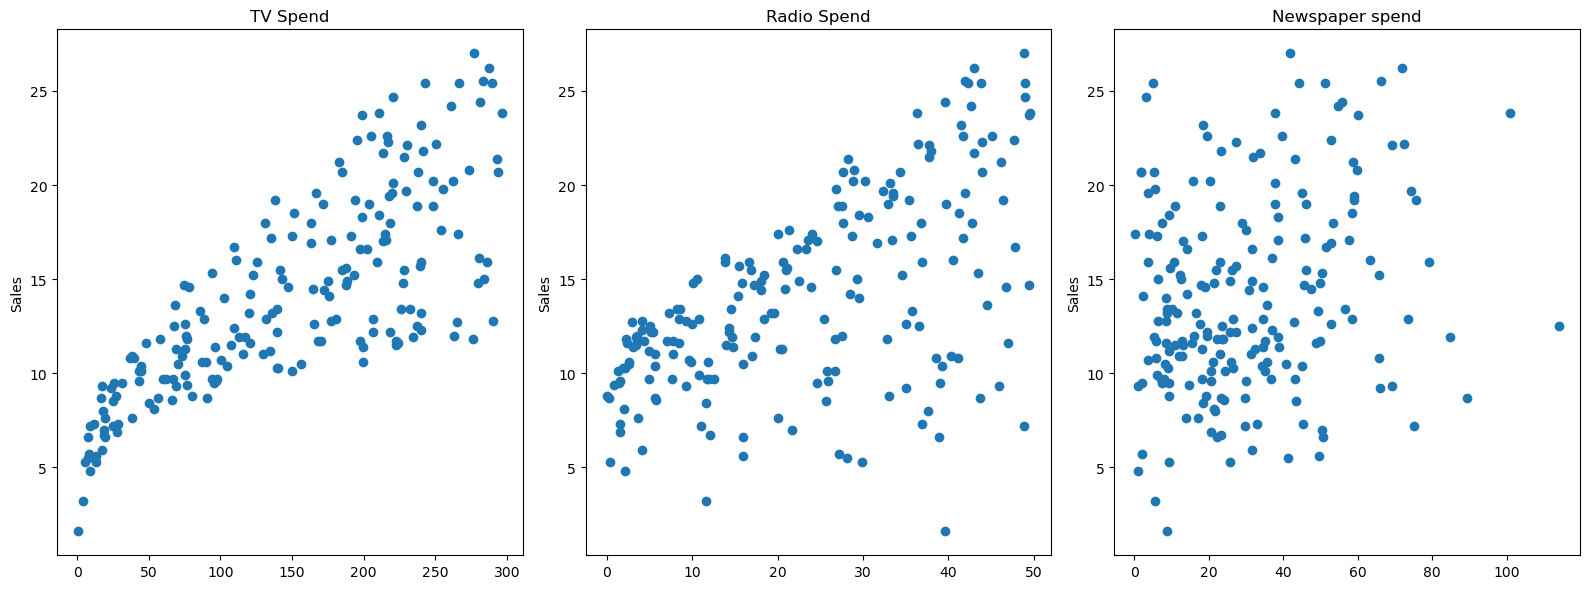

In [5]:
fig,(ax0,ax1,ax2)=plt.subplots(nrows=1,ncols=3,figsize=(16,6))

ax0.scatter(df["TV"],df["sales"])
ax0.set(
    title="TV Spend",
    ylabel="Sales"
)

ax1.scatter(df["radio"],df["sales"])
ax1.set(
    title="Radio Spend",
    ylabel="Sales"
)

ax2.scatter(df["newspaper"],df["sales"])
ax2.set(
    title="Newspaper spend",
    ylabel="Sales"
)
plt.tight_layout();


In [6]:
X=df.drop("sales",axis=1)
y=df["sales"]


In [7]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [8]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# help(train_test_split)
np.random.seed(101)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [11]:
from sklearn.linear_model import LinearRegression 
model=LinearRegression()

In [12]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
X_test.head() , y_test.head()

(        TV  radio  newspaper
 37    74.7   49.4       45.7
 109  255.4   26.9        5.5
 31   112.9   17.4       38.6
 89   109.8   47.8       51.4
 66    31.5   24.6        2.2,
 37     14.7
 109    19.8
 31     11.9
 89     16.7
 66      9.5
 Name: sales, dtype: float64)

In [14]:
test_predictions=model.predict(X_test)
test_predictions

array([15.68292592, 19.58907536, 11.33442246, 16.97160642,  9.00229777,
        6.8258424 , 20.28370847, 17.25050474,  9.62422935, 19.21261943,
       12.28165709, 13.79124205, 13.63171832, 21.3166205 , 18.4260183 ,
        9.83360121, 15.48826256,  7.50717778,  7.37608168, 20.40569824,
        7.61221263, 18.21702553, 24.75227276, 22.87105326,  7.79566192,
       12.55620637, 21.47155589,  7.89397664, 12.3119109 , 12.41822104,
       10.6650977 , 19.23984433,  9.92216352,  6.53329195, 17.27904496,
        7.60035587,  9.1023379 ,  8.10416927, 10.45284718, 10.49584758])

In [15]:
df["sales"].mean()

np.float64(14.0225)

In [16]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error

In [17]:
mean_absolute_error(y_test,test_predictions)

1.1244750006255648

In [18]:
mean_squared_error(y_test,test_predictions)

2.063418850121475

In [19]:
root_mean_squared_error(y_test,test_predictions)

1.4364605285636898

In [20]:
test_residuals = y_test-test_predictions

In [21]:
test_residuals

37    -0.982926
109    0.210925
31     0.565578
89    -0.271606
66     0.497702
119   -0.225842
54    -0.083708
74    -0.250505
145    0.675771
142    0.887381
148   -1.381657
112    0.308758
174   -2.131718
55     2.383380
141    0.773982
149    0.266399
25    -3.488263
34     1.992822
170    1.023918
39     1.094302
172   -0.012213
153    0.782974
175    2.247727
61     1.328947
65     1.504338
50    -1.156206
42    -0.771556
129    1.806023
179    0.288089
2     -3.118221
12    -1.465098
133    0.360156
90     1.277836
22    -0.933292
41    -0.179045
32     1.999644
125    1.497662
196    1.595831
158   -3.152847
180    0.004152
Name: sales, dtype: float64

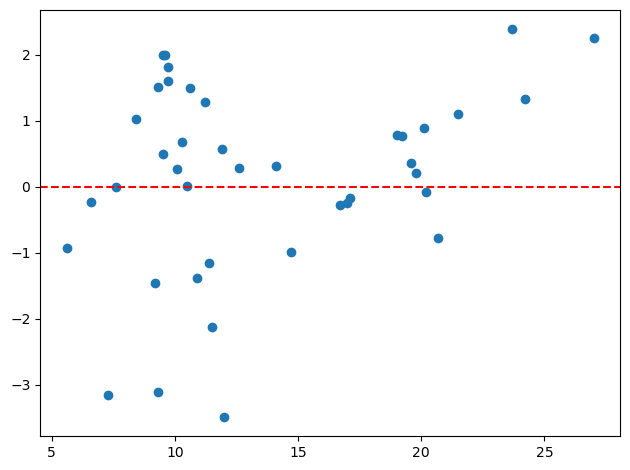

In [22]:
fig,ax=plt.subplots()
ax.scatter(x=y_test,y=test_residuals) 
plt.axhline(y=0,linestyle="--",color="red")
plt.tight_layout();

In [23]:
final_model=LinearRegression()

In [24]:
final_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
final_model.coef_


array([ 0.04576465,  0.18853002, -0.00103749])

In [26]:
 from joblib import dump,load

In [27]:
dump(final_model,'final_sales_model.joblib')

['final_sales_model.joblib']

In [28]:
loaded_model =load('final_sales_model.joblib')